In [3]:
import PKA_Sleep as PKA
import numpy as np
import os
from PKA_Sleep import Graphing_Utils as graph
import matplotlib.pyplot as plt
from neuroscience_sleep_scoring import SWS_utils
import time
import importlib
importlib.reload(SWS_utils)
graph.make_bigandbold()

In [4]:
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 100
experimental_sensor = 'FLIM-mAKAR'
sleep_states = True
microarousals = True
seperate_acqs = False
shuffled = False


experiment_names = [
    'ltFLiPAKAREEGEMG0065',
    'ltFLiPAKARmemEEGEMG0005'
                    ]
mouse_names = [
    '2647-10',
    '3707-3'
]
raw_datadirs = [os.path.join(parent_data_directory, a) for a in experiment_names]
excluded_acqs = PKA.choose_excluded_acqs(raw_datadirs, first_acqs = 0, specific_acqs = False, pull_baseline = False) 

FLP_classes_dict = PKA.build_classes(experiment_names, mouse_names, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                     exclude_acqs = excluded_acqs)

You are excluding the first 0 acquisitions of this experiment.
You are excluding the first 0 acquisitions of this experiment.
You didn't put any filter values
You didn't put any filter values


In [5]:
from datetime import datetime, timedelta
import pandas as pd
def pull_movement(datadir, acq_start, acq_len = 3600):
    movement_df = pd.read_pickle(os.path.join(datadir, 'All_movement.pkl'))
    start_ts = acq_start
    end_ts = start_ts+timedelta(seconds=acq_len)
    move_idx, = np.where(
        (movement_df['Timestamps'] < end_ts) & (movement_df['Timestamps'] > start_ts))
    this_motion = movement_df.iloc[move_idx]
    v = SWS_utils.movement_processing(this_motion, convert_to_cm = True)
    return v

vmin: -42.33458394818487; vmax: -12.231547852325217
vmin: 11.409086363377387; vmax: 40.10975480361957


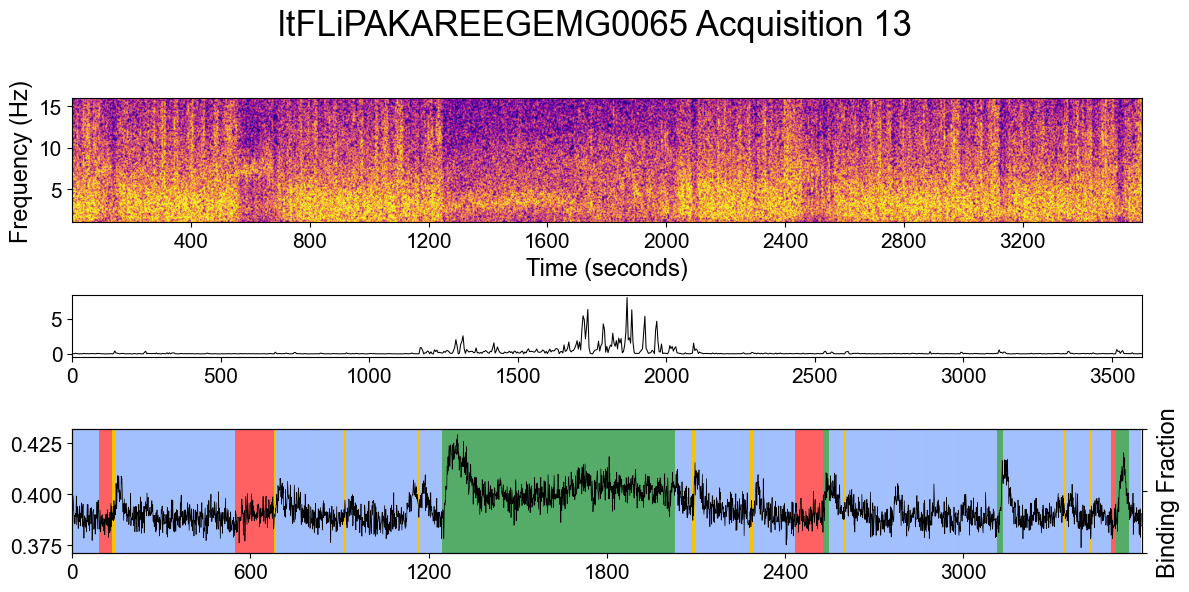

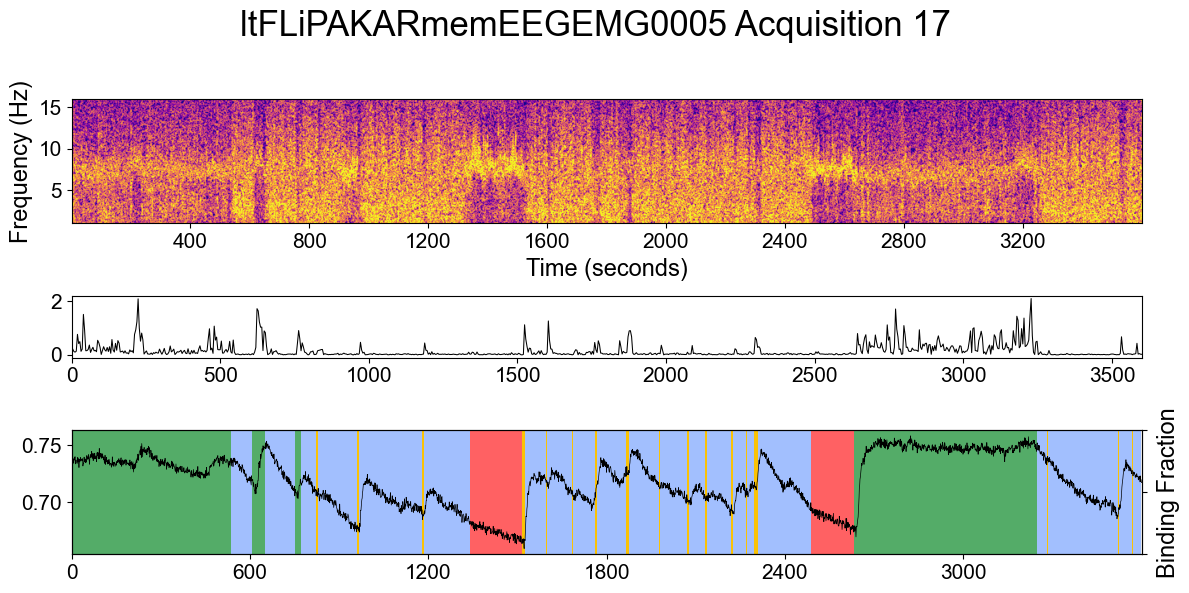

In [10]:
spec_acqs = [13, 17]
for FLP_exp, exp_name, a in zip(FLP_classes_dict['Experiment Classes'], FLP_classes_dict['Experiment Names'], spec_acqs):
    acqs = np.unique(FLP_exp.AcqNum)
    os.makedirs(os.path.join(FLP_exp.rawdatdir, 'photometry_EEG_SS_movement'), exist_ok = True)
    savedir = os.path.join(FLP_exp.rawdatdir, 'photometry_EEG_SS_movement')
    fig, ax = plt.subplots(nrows = 3, figsize = [12, 6], height_ratios = [1,0.5,1])
    acq_start = datetime.strptime(time.ctime(os.path.getmtime(
        os.path.join(parent_data_directory, exp_name, 'AD0_'+str(a)+'.mat'))), '%a %b %d %H:%M:%S %Y')-timedelta(seconds=3600)
    EEG_fn = os.path.join(parent_data_directory, exp_name, exp_name+'_extracted_data', 
                        'AD0_downsampled','downsampEEG_Acq'+str(a)+'_hr0.npy')
    
    SWS_utils.plot_spectrogram(ax[0], np.load(EEG_fn), 200, minfreq = 1, maxfreq = 16, 
                    window_length = 10, vmin = None, vmax = None)
    
    acq_idx, = np.where(FLP_exp.AcqNum == a)
    t = FLP_exp.Time[acq_idx]
    LFT = FLP_exp.Lifetime[acq_idx]
    
    SS_idx, = np.where((FLP_exp.SSTime >= t[0]) & (FLP_exp.SSTime < t[-1]))
    ss_vector = FLP_exp.SleepStates[SS_idx]
    time_vector = FLP_exp.SSTime[SS_idx]
    LFT_ax = ax[2].twinx()
    LFT_ax.plot(t, LFT, color = 'k', linewidth = 0.5, zorder = 100)
    LFT_ax.set_xlim([t[0], t[-1]])
    LFT_ax.set_xticks(np.arange(t[0], t[-1], 600))
    try:
        LFT_ax.set_xticklabels(np.arange(0, 3600, 600))
    except ValueError:
        LFT_ax.set_xticks(np.arange(t[0], t[-1], 600)[:-1])
        LFT_ax.set_xticklabels(np.arange(0, 3600, 600))
    
    PKA.plot_sleepstate_colors(ax[2], ss_vector, time_vector)
    ax[2].set_yticklabels([])
    
    v = pull_movement(os.path.join(parent_data_directory, exp_name, exp_name+'_extracted_data'), acq_start)
    ax[1].plot(v[1], v[0], color = 'k', linewidth = 0.75)
    ax[1].set_xlim([0, 3600])
    # ax[1].axis('off')
    fig.suptitle(exp_name + ' Acquisition ' + str(a) + '\n', fontsize = 25)
    
    graph.label_axes(ax[2], y = FLP_exp.PhosMeasure)
    ax[2].yaxis.set_label_position("right")
    ax[2].yaxis.tick_right()
    LFT_ax.yaxis.set_label_position("left")
    LFT_ax.yaxis.tick_left()
    
    
    fig.tight_layout()
    fig.savefig(os.path.join(savedir, 'Acq'+str(a)+'.png'))
    # plt.close('all')

In [16]:
FLP_exp.rawdatdir

'/Volumes/yaochen/Active/Lizzie/FLP_data/ltFLiPAKARmemEEGEMG0123-2'

In [14]:
FLP_classes_dict['Experiment Classes']